# 🏙️ Barcelona Housing Market Intelligence: From Data to Investment Strategy
## A Comprehensive Analysis of Market Segments, Fair Value, and Investment Opportunities

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.cluster import KMeans
from sklearn.preprocessing import RobustScaler
from math import pi

# Suppress font warnings for emojis in local environments
warnings.filterwarnings("ignore", category=UserWarning, module="matplotlib")

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# 📂 HYBRID PATH DETECTION (Local vs Kaggle)
KAGGLE_PATH = '../input/barcelona-housing-market-intelligence-2024/barcelona_ml_valuation.csv'
LOCAL_PATH = '../data/barcelona_ml_valuation.csv'

# Check environment and file availability
if os.path.exists(KAGGLE_PATH):
    PATH = KAGGLE_PATH
elif os.path.exists(LOCAL_PATH):
    PATH = LOCAL_PATH
else:
    PATH = 'barcelona_ml_valuation.csv'

# Load data
if os.path.exists(PATH):
    df = pd.read_csv(PATH)
    print(f"✅ Dataset loaded: {len(df)} neighborhoods.")
    df = df.fillna(0)
else:
    print(f"❌ Error: File not found at {PATH}")


✅ Dataset loaded: 73 neighborhoods.


## 2. Neighborhood Segmentation (Asset Classes)
Real estate is heterogeneous. We cluster neighborhoods based on Yield, Income, Effort Rate, and Growth.

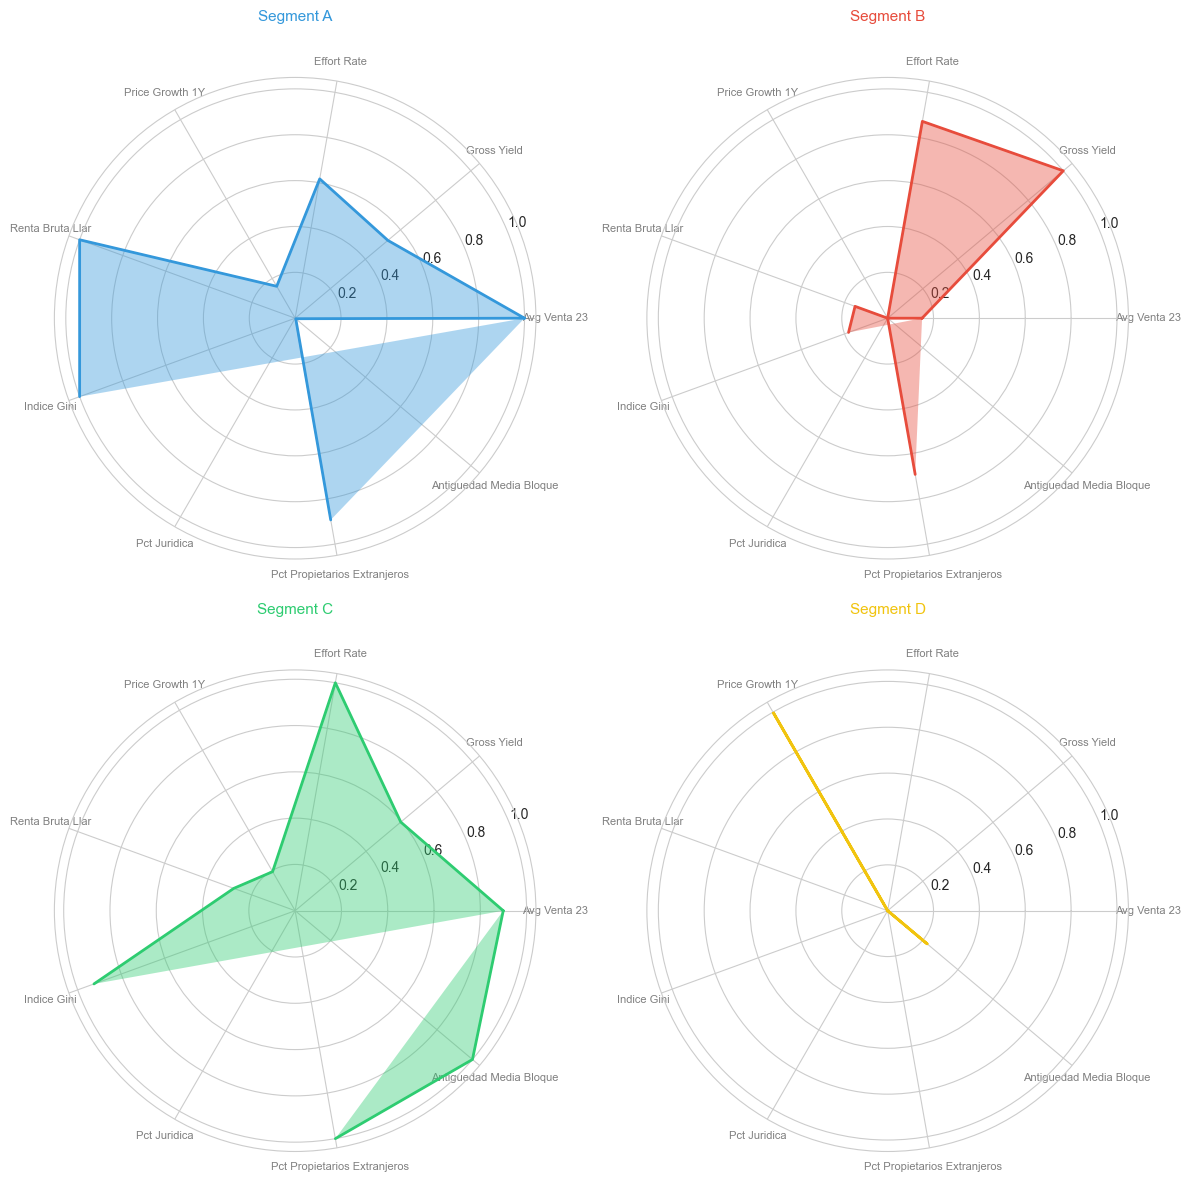

In [2]:
cluster_vars = [
    'avg_venta_23', 'gross_yield', 'effort_rate', 
    'price_growth_1y', 'renta_bruta_llar', 'indice_gini', 
    'pct_juridica', 'pct_propietarios_extranjeros', 'antiguedad_media_bloque'
]

# 1. Scaling for clustering
scaler = RobustScaler()
X_scaled = scaler.fit_transform(df[cluster_vars])

# 2. K-Means Clustering
kmeans = KMeans(n_clusters=4, random_state=42)
df['segmento'] = kmeans.fit_predict(X_scaled)

# 3. Analyze Centroids
centroids = df.groupby('segmento')[cluster_vars].mean()
norm_centroids = (centroids - centroids.min()) / (centroids.max() - centroids.min())

# Radar Chart Function
def make_radar(row, title, color, idx):
    categories = [c.replace('_', ' ').title() for c in cluster_vars]
    N = len(categories)
    values = row.values.flatten().tolist()
    values += values[:1]
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]
    
    ax = plt.subplot(2, 2, idx, polar=True)
    plt.xticks(angles[:-1], categories, color='grey', size=8)
    ax.plot(angles, values, color=color, linewidth=2, linestyle='solid')
    ax.fill(angles, values, color=color, alpha=0.4)
    plt.title(title, size=11, color=color, y=1.1)

plt.figure(figsize=(12, 12))
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f1c40f']
titles = ['Segment A', 'Segment B', 'Segment C', 'Segment D']

for i in range(4):
    make_radar(norm_centroids.iloc[i], titles[i], colors[i], i+1)

plt.tight_layout()
plt.show()

### 💡 Refining the Model: The Topographical Penalty Index
Traditional ML models often flag mountainous neighborhoods (like **El Coll**) as 'undervalued' because they don't account for physical constraints like steep slopes or accessibility issues.

We introduced a manual **Topographical Penalty Index** to adjust for:
*   **Steep Orography:** Difficult access and urban fragmentation.
*   **Accessibility Gaps:** Depth of metro stations (e.g., El Coll is the deepest in BCN) and lack of elevators in steep streets.

This allows the model to distinguish between a **genuine bargain** and a **structural price reduction**.

## 3. Machine Learning: Prediction of Fair Value

📊 Model Metrics (XGBoost): MAE = 346.66 €/m2 | R2 = 0.7925


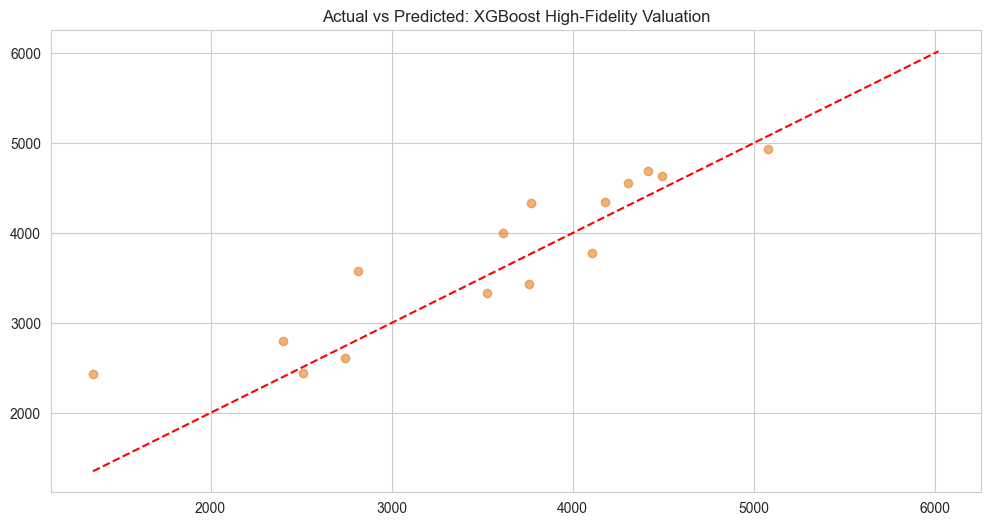

✅ Desviación de valor calculada para todos los barrios.


In [3]:
# Expanded physical features
features = [
    'renta_bruta_llar', 'indice_penalizacion_topografica', 'access_penalty',
    'dist_to_center', 'dist_to_tech_hub', 'gross_yield', 'effort_rate', 
    'indice_gini', 'pct_propietarios_extranjeros', 'antiguedad_media_bloque', 
    'pct_juridica', 'price_growth_1y'
]

# Prepare data
df_clean = df.dropna(subset=features + ['avg_venta_23']).copy()
X = df_clean[features]
y = df_clean['avg_venta_23']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Transition to XGBoost for higher fidelity
model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'📊 Model Metrics (XGBoost): MAE = {mae:.2f} €/m2 | R2 = {r2:.4f}')

plt.scatter(y_test, y_pred, alpha=0.6, color='#e67e22')
plt.plot([y.min(), y.max()], [y.min(), y.max()], '--r')
plt.title('Actual vs Predicted: XGBoost High-Fidelity Valuation')
plt.show()

# Calculate Fair Value Deviation for the Simulator
df['precio_estimado'] = model.predict(df[features])
df['desviacion_valor'] = ((df['avg_venta_23'] - df['precio_estimado']) / df['precio_estimado']) * 100
print('✅ Desviación de valor calculada para todos los barrios.')


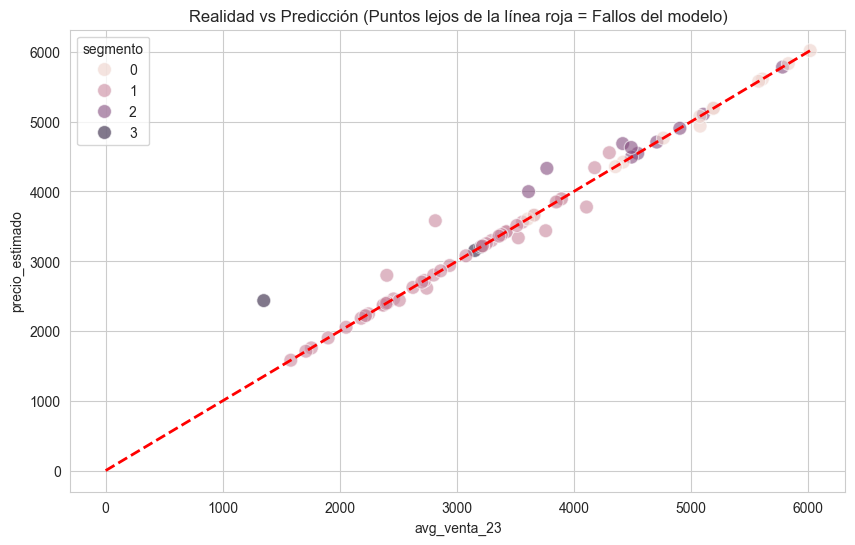

⚠️ FALSAS OPORTUNIDADES (Sobreestimación - Posibles 'Value Traps'):


,barrio_nombre,avg_venta_23,precio_estimado,error,error_pct
55,Vallbona,1350.838672,2435.976807,-1085.138135,-80.330698
28,el Coll,2816.464274,3580.868408,-764.404134,-27.140559
0,el Raval,3769.646932,4331.684570,-562.037638,-14.909556
45,el Turó de la Peira,2402.220540,2798.453369,-396.232829,-16.494440
10,el Poble-sec,3612.973022,3998.060059,-385.087036,-10.658453



💎 JOYAS OCULTAS REALES (Subestimación - Oportunidades potenciales):


,barrio_nombre,avg_venta_23,precio_estimado,error,error_pct
31,el Camp d'en Grassot i Gràcia Nova,4108.215129,3777.288818,330.926310,8.055233
63,el Camp de l'Arpa del Clot,3759.628174,3437.233887,322.394287,8.575164
34,el Guinardó,3525.325887,3336.083740,189.242147,5.368075
18,les Corts,5078.461833,4936.705078,141.756755,2.791332
12,la Marina de Port,2743.183512,2613.962158,129.221354,4.710635


In [4]:
# 3.1 DIAGNÓSTICO: ANÁLISIS DE RESIDUALES (Gaps de Precisión)
df_diag = df.dropna(subset=features + ['avg_venta_23']).copy()
# Generamos predicciones para todo el dataset para el diagnóstico
df_diag['precio_estimado'] = model.predict(df_diag[features])
df_diag['error'] = df_diag['avg_venta_23'] - df['precio_estimado']
df_diag['error_pct'] = (df_diag['error'] / df_diag['avg_venta_23']) * 100

def analyze_residuals(df_results):
    # 1. Gráfico de Dispersión: Real vs Predicho
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=df_results, x='avg_venta_23', y='precio_estimado', hue='segmento', alpha=0.6, s=100)
    max_v = max(df_results['avg_venta_23'].max(), df_results['precio_estimado'].max())
    plt.plot([0, max_v], [0, max_v], 'r--', lw=2) # Línea de perfección
    plt.title("Realidad vs Predicción (Puntos lejos de la línea roja = Fallos del modelo)")
    plt.show()
    
    # 2. Top 5 Barrios donde el modelo SOBREESTIMA (Falsas Oportunidades)
    overestimated = df_results.sort_values('error', ascending=True).head(5)
    print("⚠️ FALSAS OPORTUNIDADES (Sobreestimación - Posibles 'Value Traps'):")
    display(overestimated[['barrio_nombre', 'avg_venta_23', 'precio_estimado', 'error', 'error_pct']])

    # 3. Top 5 Barrios donde el modelo SUBESTIMA (Joyas Ocultas Reales)
    underestimated = df_results.sort_values('error', ascending=False).head(5)
    print("\n💎 JOYAS OCULTAS REALES (Subestimación - Oportunidades potenciales):")
    display(underestimated[['barrio_nombre', 'avg_venta_23', 'precio_estimado', 'error', 'error_pct']])

analyze_residuals(df_diag)

## 4. Investment Simulator

In [5]:
def investment_consultant(budget, strategy='yield'):
    options = df[df['avg_venta_23'] * 65 <= budget].copy()
    if options.empty: return "No options found for this budget."
    
    if strategy == 'yield':
        reco = options.sort_values('gross_yield', ascending=False).head(3)
    elif strategy == 'safe':
        reco = options.sort_values('desviacion_valor', ascending=True).head(3)
    else:
        reco = options.sort_values('price_growth_1y', ascending=False).head(3)
        
    return reco[['barrio_nombre', 'avg_venta_23', 'gross_yield', 'desviacion_valor', 'segmento']]

print("💡 Recommendation for a €250,000 budget (Focus on Cash-Flow):")
display(investment_consultant(250000, strategy='yield'))

💡 Recommendation for a €250,000 budget (Focus on Cash-Flow):


,barrio_nombre,avg_venta_23,gross_yield,desviacion_valor,segmento
11,la Marina del Prat Vermell,2246.260010,8.007757,-0.000315,1
72,la Verneda i la Pau,2508.738729,7.381131,2.802092,1
49,les Roquetes,2053.878296,7.206794,0.000196,1
